In [1]:
import os
import pandas as pd
import yaml

cfg = yaml.safe_load(open('configs/settings.yaml'))

In [2]:
SECTORS = {
    '00000000': 'Total nonfarm',
    '10000000': 'Mining, Logging, and Construction',
    '15000000': 'Mining, Logging, and Construction',
    '20000000': 'Mining, Logging, and Construction',
    '30000000': 'Manufacturing',
    '40000000': 'Trade, Transportation, and Utilities',
    '50000000': 'Information',
    '55000000': 'Financial Activities',
    '60000000': 'Professional and Business Services',
    '65000000': 'Private Education and Health Services',
    '70000000': 'Leisure and Hospitality',
    '80000000': 'Other Services',
    '90000000': 'Government',
}

In [3]:
ces_us_path = os.path.join(cfg['data_dir'], cfg['ces_us_file'])
us = pd.read_excel(ces_us_path, skiprows=3)

c:\Users\jkolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
ces_region_path = os.path.join(cfg['data_dir'], cfg['ces_emp_region_file'])
region = pd.read_excel(ces_region_path, skiprows=3)
region

c:\Users\jkolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Series ID,Annual\n1990,Annual\n1991,Annual\n1992,Annual\n1993,Annual\n1994,Annual\n1995,Annual\n1996,Annual\n1997,Annual\n1998,...,Annual\n2017,Annual\n2018,Annual\n2019,Annual\n2020,Annual\n2021,Annual\n2022,Annual\n2023,Annual\n2024,Annual\n2025,Annual\n2026
0,SMU53147400000000001,65.0,66.9,67.8,68.1,69.0,69.4,70.6,71.9,71.5,...,90.7,93.4,95.3,90.6,91.5,94.6,95.9,96.1,97.0,NaN
1,SMU53426600000000001,1304.5,1311.0,1329.2,1347.9,1365.7,1392.2,1440.9,1520.0,1588.5,...,1997.3,2043.7,2089.7,1973.4,2009.9,2098.5,2115.7,2124.6,2125.0,NaN
2,SMU53147401500000001,3.4,3.2,3.4,3.5,3.6,3.6,3.6,3.5,3.7,...,4.6,5.0,5.2,5.1,5.2,5.2,4.9,4.7,4.7,NaN
3,SMU53426601500000001,76.6,73.3,75.1,72.4,71.9,72.3,75.1,81.7,88.2,...,120.9,127.7,129.9,125.7,130.6,132.9,129.9,124.3,121.0,NaN
4,SMU53147403000000001,1.3,1.3,1.3,1.2,1.4,1.3,1.6,1.5,1.7,...,2.8,2.8,2.9,2.7,2.7,2.9,2.7,2.6,2.8,NaN
5,SMU53426603000000001,232.2,226.7,222.2,212.9,203.0,198.5,209.4,233.5,244.2,...,178.6,178.8,184.3,168.7,155.8,160.3,164.6,165.6,163.9,NaN
6,SMU53147404000000001,9.4,10.0,10.1,10.3,10.5,10.6,11.1,11.3,11.4,...,13.6,14.0,13.9,13.1,13.4,13.7,13.8,13.4,13.4,NaN
7,SMU53426604000000001,268.8,268.2,268.4,270.7,274.1,281.3,289.4,297.5,309.0,...,351.5,354.2,354.7,338.6,351.5,355.8,356.2,351.7,351.3,NaN
8,SMU53147405000000001,1.3,1.2,1.2,1.3,1.4,1.4,1.5,1.5,1.6,...,1.0,1.0,0.9,0.7,0.7,0.8,0.8,0.9,0.9,NaN
9,SMU53426605000000001,34.8,36.4,38.4,41.2,43.6,49.0,53.2,56.7,60.3,...,111.2,118.6,128.4,133.5,139.2,146.8,140.9,134.7,132.1,NaN


In [5]:
def ces_to_long(df, id_col='Series ID'):
    long_df = df.melt(id_vars=[id_col], var_name='year', value_name='employment')
    long_df['year'] = long_df['year'].str.extract(r'(\d{4})').astype(int)
    # last 10 chars of the Series ID are <8-digit sector code><2-digit data type code>
    long_df['sector'] = long_df[id_col].str[-10:-2].map(SECTORS)
    long_df = long_df.dropna(subset=['sector', 'employment'])
    # combine sector codes that map to the same label (e.g. historical vs. current
    # supersector splits) and, for regional data, sum across the constituent areas
    return long_df.groupby(['sector', 'year'], as_index=False)['employment'].sum()

us_long = ces_to_long(us)
region_long = ces_to_long(region)

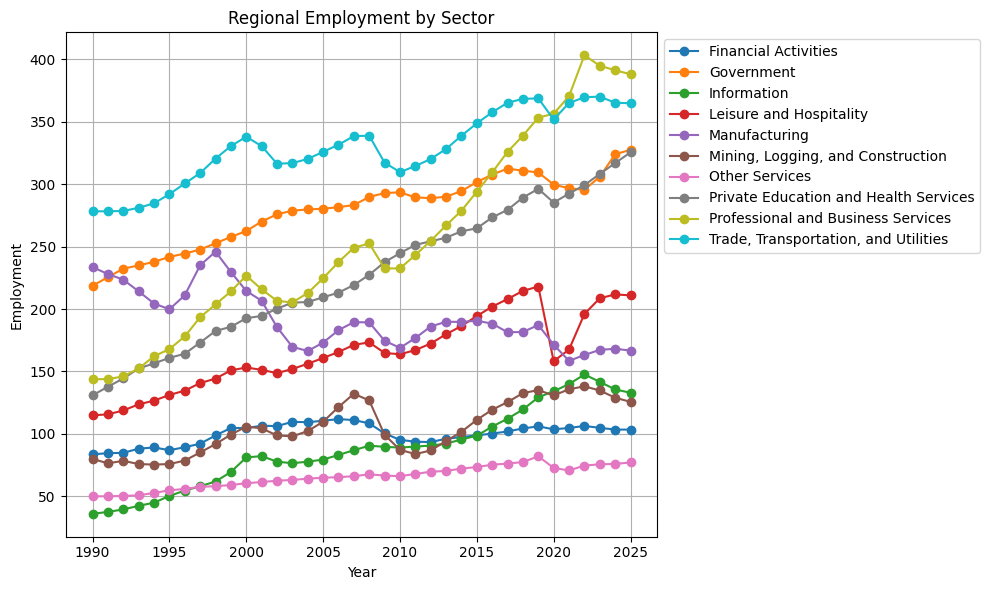

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for sector, group in region_long[region_long['sector'] != 'Total nonfarm'].groupby('sector'):
    ax.plot(group['year'], group['employment'], marker='o', label=sector)
ax.set_xlabel('Year')
ax.set_ylabel('Employment')
ax.set_title('Regional Employment by Sector')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid()
plt.tight_layout()
plt.show()

In [11]:
def decade_cagr(df):
    d = df.copy()
    d['decade'] = (d['year'] // 10) * 10
    rows = []
    for (sector, decade), g in d.groupby(['sector', 'decade']):
        g = g.sort_values('year')
        start_year, end_year = g['year'].iloc[0], g['year'].iloc[-1]
        start_val, end_val = g['employment'].iloc[0], g['employment'].iloc[-1]
        n_years = end_year - start_year
        # skip decades with only one year of data (can't compute a growth rate)
        if n_years == 0:
            continue
        cagr = (end_val / start_val) ** (1 / n_years) - 1
        rows.append({'sector': sector, 'decade': decade, 'cagr': cagr})
    return pd.DataFrame(rows)

cagr_us = decade_cagr(us_long).assign(geography='National')
cagr_region = decade_cagr(region_long).assign(geography='Regional')
cagr_all = pd.concat([cagr_us, cagr_region], ignore_index=True)
cagr_all = cagr_all[cagr_all['sector'] != 'Total nonfarm']


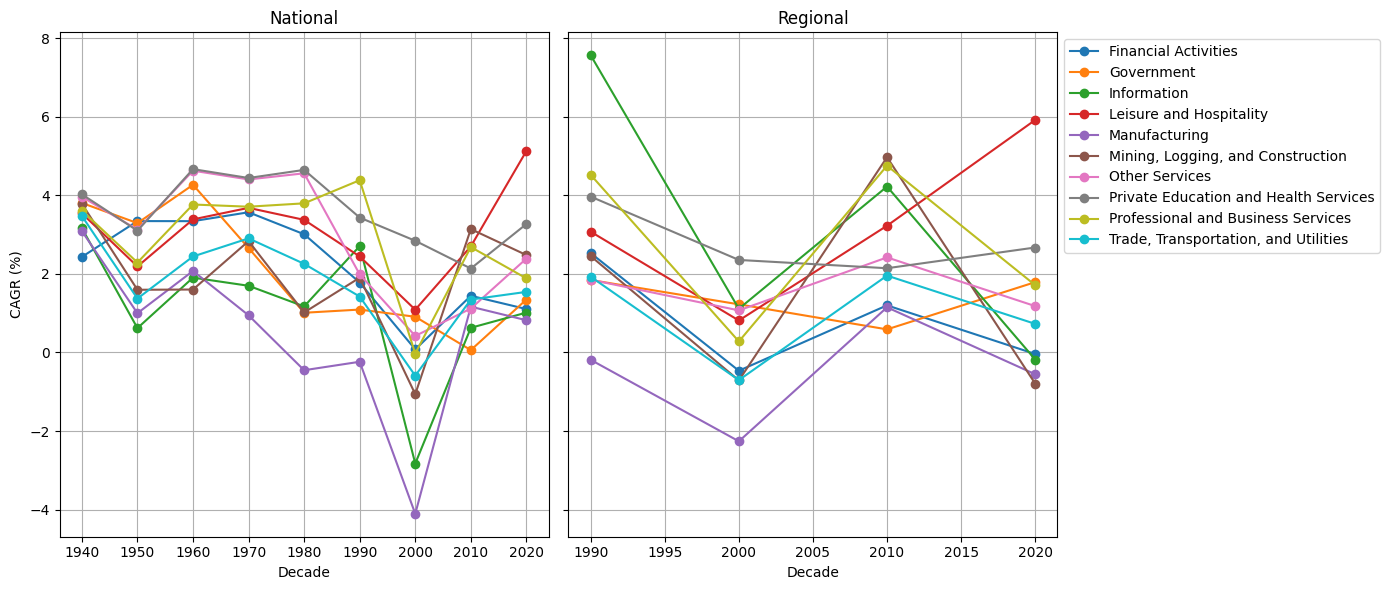

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (geo, sub) in zip(axes, cagr_all.groupby('geography')):
    for sector, g in sub.sort_values('decade').groupby('sector'):
        ax.plot(g['decade'], g['cagr'] * 100, marker='o', label=sector)
    ax.set_title(geo)
    ax.set_xlabel('Decade')
    ax.grid()
axes[0].set_ylabel('CAGR (%)')
axes[-1].legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [13]:
cagr_table = cagr_all.pivot_table(index='sector', columns=['geography', 'decade'], values='cagr')
cagr_table.style.format('{:.1%}')
